# notebooks/exploratory_data.ipynb

#### This notebook inspects the benchmark composition and verify that the dataset matches the promised 200–300 tasks, four source modes, pair integrity, and train/dev/held-out layout. Week 11 requires 200–300 tasks, source-mode metadata, and 50/30/20 partitioning.

## 1. Setup

In [1]:
from pathlib import Path
import json
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

TASK_FILES = {
    "trace_tasks": ROOT / "data" / "tasks" / "trace_tasks.json",
    "programmatic_tasks": ROOT / "data" / "tasks" / "programmatic_tasks.json",
    "synthetic_pairs": ROOT / "data" / "tasks" / "synthetic_pairs.json",
    "adversarial_cases": ROOT / "data" / "tasks" / "adversarial_cases.json",
}

SPLIT_FILES = {
    "train": ROOT / "tenacious_bench" / "train" / "train.jsonl",
    "dev": ROOT / "tenacious_bench" / "dev" / "dev.jsonl",
    "held_out": ROOT / "tenacious_bench" / "held_out" / "held_out.jsonl",
}

DPO_FILES = {
    "train_dpo": ROOT / "tenacious_bench" / "dpo" / "train_dpo.jsonl",
    "dev_dpo": ROOT / "tenacious_bench" / "dpo" / "dev_dpo.jsonl",
    "held_out_dpo": ROOT / "tenacious_bench" / "dpo" / "held_out_dpo.jsonl",
}

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

## 2. Load and summarize task files

In [2]:
task_rows = []

for name, path in TASK_FILES.items():
    assert path.exists(), f"Missing task file: {path}"
    rows = load_json(path)
    for row in rows:
        row["_task_file"] = name
    task_rows.extend(rows)

tasks_df = pd.DataFrame(task_rows)

task_summary = {
    "total_candidate_tasks": len(tasks_df),
    "task_files": {
        name: len(load_json(path))
        for name, path in TASK_FILES.items()
    },
    "source_mode_counts": tasks_df["source_mode"].value_counts(dropna=False).to_dict(),
    "label_counts": tasks_df["label"].value_counts(dropna=False).to_dict(),
    "failure_code_counts": tasks_df.get("failure_code", pd.Series(dtype=str)).value_counts(dropna=False).to_dict(),
}

task_summary

{'total_candidate_tasks': 436,
 'task_files': {'trace_tasks': 176,
  'programmatic_tasks': 102,
  'synthetic_pairs': 96,
  'adversarial_cases': 62},
 'source_mode_counts': {'trace-derived': 176,
  'programmatic': 102,
  'multi-LLM synthesis': 96,
  'hand-authored adversarial': 62},
 'label_counts': {1: 218, 0: 218},
 'failure_code_counts': {'None': 218,
  'F3.2': 58,
  'F1.2': 51,
  'F3.1': 25,
  'F3.3': 17,
  'F2.2': 16,
  'F4.2': 9,
  'F2.1': 9,
  'F4.3': 8,
  'F1.1': 8,
  'F4.1': 6,
  'F1.4': 6,
  'F2.3': 5}}

## 3. Load split files

In [3]:
split_rows = []

for split, path in SPLIT_FILES.items():
    assert path.exists(), f"Missing split file: {path}"
    rows = load_jsonl(path)
    for row in rows:
        row["_split"] = split
    split_rows.extend(rows)

splits_df = pd.DataFrame(split_rows)

split_summary = {
    "total_selected_tasks": len(splits_df),
    "split_counts": splits_df["_split"].value_counts().to_dict(),
    "source_mode_by_split": (
        splits_df.groupby(["_split", "source_mode"]).size().unstack(fill_value=0).to_dict()
        if "source_mode" in splits_df.columns else {}
    ),
    "label_counts_by_split": (
        splits_df.groupby(["_split", "label"]).size().unstack(fill_value=0).to_dict()
        if "label" in splits_df.columns else {}
    ),
}

split_summary

{'total_selected_tasks': 260,
 'split_counts': {'train': 130, 'dev': 78, 'held_out': 52},
 'source_mode_by_split': {'hand-authored adversarial': {'dev': 18,
   'held_out': 10,
   'train': 12},
  'multi-LLM synthesis': {'dev': 18, 'held_out': 6, 'train': 40},
  'programmatic': {'dev': 18, 'held_out': 14, 'train': 46},
  'trace-derived': {'dev': 24, 'held_out': 22, 'train': 32}},
 'label_counts_by_split': {0: {'dev': 39, 'held_out': 26, 'train': 65},
  1: {'dev': 39, 'held_out': 26, 'train': 65}}}

## 4. Pair integrity checks

In [4]:
pair_checks = {}

for split, split_df in splits_df.groupby("_split"):
    by_pair = split_df.groupby("pair_id")["label"].apply(list)
    complete_pairs = by_pair.apply(lambda labels: sorted(labels) == [0, 1]).sum()
    total_pairs = by_pair.shape[0]
    broken_pairs = total_pairs - complete_pairs

    pair_checks[split] = {
        "total_pairs": int(total_pairs),
        "complete_pairs": int(complete_pairs),
        "broken_pairs": int(broken_pairs),
    }

pair_checks

{'dev': {'total_pairs': 39, 'complete_pairs': 39, 'broken_pairs': 0},
 'held_out': {'total_pairs': 26, 'complete_pairs': 26, 'broken_pairs': 0},
 'train': {'total_pairs': 65, 'complete_pairs': 65, 'broken_pairs': 0}}

## 5. DPO files

In [5]:
dpo_summary = {}

for name, path in DPO_FILES.items():
    assert path.exists(), f"Missing DPO file: {path}"
    rows = load_jsonl(path)

    missing_required = []
    for i, row in enumerate(rows):
        for key in ["prompt", "chosen", "rejected"]:
            if key not in row or not isinstance(row[key], str) or not row[key].strip():
                missing_required.append((i, key))

    dpo_summary[name] = {
        "pairs": len(rows),
        "missing_required_examples": missing_required[:5],
    }

dpo_summary

{'train_dpo': {'pairs': 65, 'missing_required_examples': []},
 'dev_dpo': {'pairs': 39, 'missing_required_examples': []},
 'held_out_dpo': {'pairs': 26, 'missing_required_examples': []}}

## 6. Charts

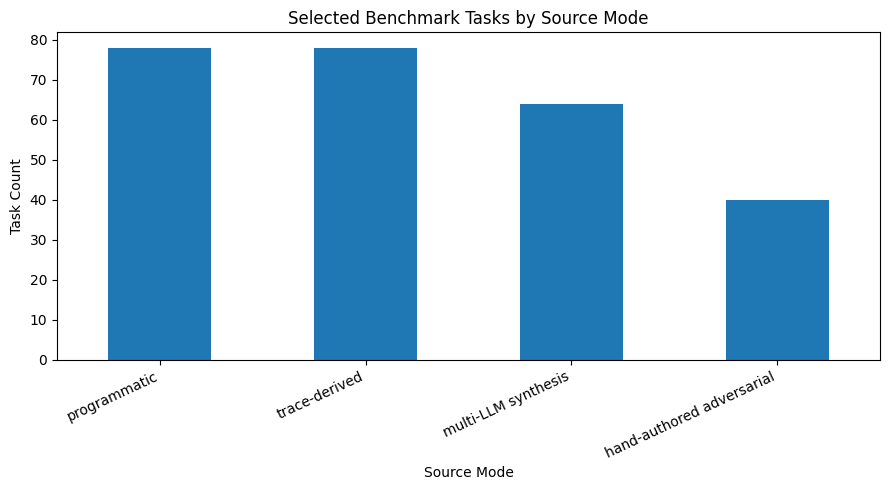

Saved: ..\reports\dataset_source_mode_composition.png


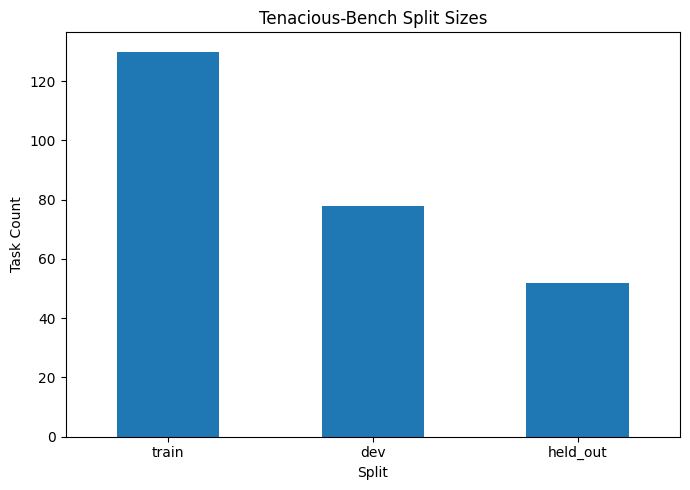

Saved: ..\reports\dataset_split_sizes.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
splits_df["source_mode"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Selected Benchmark Tasks by Source Mode")
ax.set_ylabel("Task Count")
ax.set_xlabel("Source Mode")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

out = REPORTS / "dataset_source_mode_composition.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")

fig, ax = plt.subplots(figsize=(7, 5))
splits_df["_split"].value_counts().reindex(["train", "dev", "held_out"]).plot(kind="bar", ax=ax)
ax.set_title("Tenacious-Bench Split Sizes")
ax.set_ylabel("Task Count")
ax.set_xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()

out = REPORTS / "dataset_split_sizes.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")

## 7. Save summary

In [7]:
exploratory_summary = {
    "task_summary": task_summary,
    "split_summary": split_summary,
    "pair_integrity": pair_checks,
    "dpo_summary": dpo_summary,
}

out = REPORTS / "exploratory_data_summary.json"
with open(out, "w", encoding="utf-8") as f:
    json.dump(exploratory_summary, f, indent=2, ensure_ascii=False)

exploratory_summary

{'task_summary': {'total_candidate_tasks': 436,
  'task_files': {'trace_tasks': 176,
   'programmatic_tasks': 102,
   'synthetic_pairs': 96,
   'adversarial_cases': 62},
  'source_mode_counts': {'trace-derived': 176,
   'programmatic': 102,
   'multi-LLM synthesis': 96,
   'hand-authored adversarial': 62},
  'label_counts': {1: 218, 0: 218},
  'failure_code_counts': {'None': 218,
   'F3.2': 58,
   'F1.2': 51,
   'F3.1': 25,
   'F3.3': 17,
   'F2.2': 16,
   'F4.2': 9,
   'F2.1': 9,
   'F4.3': 8,
   'F1.1': 8,
   'F4.1': 6,
   'F1.4': 6,
   'F2.3': 5}},
 'split_summary': {'total_selected_tasks': 260,
  'split_counts': {'train': 130, 'dev': 78, 'held_out': 52},
  'source_mode_by_split': {'hand-authored adversarial': {'dev': 18,
    'held_out': 10,
    'train': 12},
   'multi-LLM synthesis': {'dev': 18, 'held_out': 6, 'train': 40},
   'programmatic': {'dev': 18, 'held_out': 14, 'train': 46},
   'trace-derived': {'dev': 24, 'held_out': 22, 'train': 32}},
  'label_counts_by_split': {0: {'dev